# 22 — Price Elasticity of Demand (City vs Resort)

Ước lượng **độ co giãn giá–demand** từ lịch sử stay bookings (`hotel_bookings_v5.csv`), tách **City Hotel / Resort Hotel**.

**Mục tiêu**

1. Panel tháng: demand · ADR · Occ · RevPAR  
2. Elasticity **log–log OLS** per hotel (+ month FE)  
3. Elasticity **first-difference** (robust hơn trend)  
4. Sanity: ADR–demand scatter, fitted curve  
5. Xuất `elasticity_by_hotel.csv` cho notebook **23** (optimization)

**Công thức:** $\varepsilon = \partial \log Q / \partial \log P$ — kỳ vọng $\varepsilon < 0$.

**Phạm vi:** stay (`is_canceled=0`, `adr>0`) · ~26 tháng/hotel · recommend-only.

In [ ]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "22_elasticity"
FIG_DIR.mkdir(parents=True, exist_ok=True)
for slug in ("city", "resort", "compare"):
    (FIG_DIR / slug).mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
HOTELS = ["City Hotel", "Resort Hotel"]
SLUG = {"City Hotel": "city", "Resort Hotel": "resort"}

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")

ROOT: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\22_elasticity


In [ ]:
def savefig(name: str, slug: str | None = None, dpi: int = 120) -> Path:
    folder = FIG_DIR if slug is None else FIG_DIR / slug
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def load_stay() -> pd.DataFrame:
    usecols = [
        "hotel", "is_canceled", "adr", "arrival_date_year", "arrival_date_month",
        "Occupancy_Rate", "RevPAR", "revenue", "lead_time", "market_segment",
        "customer_type", "total_of_special_requests", "stays_in_weekend_nights",
        "stays_in_week_nights",
    ]
    df = pd.read_csv(DATA_PATH, usecols=usecols)
    stay = df[(df["is_canceled"] == 0) & (df["adr"] > 0)].copy()
    stay["month"] = stay["arrival_date_month"].map(MONTH_MAP)
    stay["ym"] = pd.to_datetime(
        dict(year=stay["arrival_date_year"], month=stay["month"], day=1)
    )
    stay["los"] = stay["stays_in_weekend_nights"] + stay["stays_in_week_nights"]
    return stay


def monthly_panel(stay: pd.DataFrame) -> pd.DataFrame:
    g = (
        stay.groupby(["hotel", "ym"], as_index=False)
        .agg(
            demand=("adr", "size"),
            adr=("adr", "mean"),
            occ=("Occupancy_Rate", "mean"),
            revpar=("RevPAR", "mean"),
            lead_mean=("lead_time", "mean"),
            lead_p50=("lead_time", "median"),
            los_mean=("los", "mean"),
            special_req=("total_of_special_requests", "mean"),
            share_online_ta=("market_segment", lambda s: (s == "Online TA").mean()),
            share_groups=("market_segment", lambda s: (s == "Groups").mean()),
            share_transient=("customer_type", lambda s: (s == "Transient").mean()),
        )
        .sort_values(["hotel", "ym"])
        .reset_index(drop=True)
    )
    g["month"] = g["ym"].dt.month
    g["log_demand"] = np.log(g["demand"].clip(lower=1))
    g["log_adr"] = np.log(g["adr"].clip(lower=1e-3))
    g["log_revpar"] = np.log(g["revpar"].clip(lower=1e-3))
    return g


def read_forecast_bundle() -> pd.DataFrame:
    """Primary point forecasts + stance from notebooks 20 / 20a / 20b."""
    MODEL_COL = {
        "seasonal_naive": "seasonal_naive",
        "holt_trend": "holt_winters",
        "holt_winters": "holt_winters",
        "holt_winters_seasonal": "holt_winters",
        "sarimax": "sarimax",
    }
    specs = [
        ("demand", "20", "demand_index"),
        ("adr", "20_adr", "metric_index"),
        ("revpar", "20_revpar", "metric_index"),
    ]
    metric_frames = []
    for metric, sub, idx_col in specs:
        hotel_parts = []
        for hotel, slug in SLUG.items():
            fc_path = ROOT / "reports" / "figures" / sub / slug / "forecast_next_6m.csv"
            st_path = ROOT / "reports" / "figures" / sub / slug / "pricing_stance_forecast.csv"
            if not fc_path.exists() or not st_path.exists():
                raise FileNotFoundError(f"Missing forecast artifacts: {fc_path} or {st_path}")
            fc = pd.read_csv(fc_path, parse_dates=["ym"])
            st = pd.read_csv(st_path, parse_dates=["ym"])
            model = str(st["forecast_model"].iloc[0])
            col = MODEL_COL.get(model, model)
            if col not in fc.columns:
                # last resort: pricing stance already stores the primary point forecast
                yhat = st["forecast"]
            else:
                yhat = fc[col]
            tmp = pd.DataFrame({
                "hotel": hotel,
                "ym": st["ym"].values if len(st) == len(yhat) else fc["ym"].values,
                f"fc_{metric}": np.asarray(yhat, dtype=float),
                f"model_{metric}": model,
            })
            st2 = st[["ym", "season_index", idx_col, "combined_pressure", "pricing_stance"]].copy()
            st2 = st2.rename(columns={
                idx_col: f"index_{metric}",
                "season_index": f"season_{metric}",
                "combined_pressure": f"pressure_{metric}",
                "pricing_stance": f"stance_{metric}",
            })
            tmp = tmp.merge(st2, on="ym", how="left")
            hotel_parts.append(tmp)
        metric_frames.append(pd.concat(hotel_parts, ignore_index=True))
    base = metric_frames[0]
    for part in metric_frames[1:]:
        base = base.merge(part, on=["hotel", "ym"], how="outer")
    return base.sort_values(["hotel", "ym"]).reset_index(drop=True)

In [ ]:
stay = load_stay()
panel = monthly_panel(stay)
display(panel.groupby("hotel")[["demand", "adr", "occ", "revpar"]].describe().round(2))
panel.to_csv(FIG_DIR / "monthly_panel.csv", index=False)
print(f"Saved: {(FIG_DIR / 'monthly_panel.csv').relative_to(ROOT)}")

demand                                                           \
              count     mean     std    min      25%     50%     75%     max   
hotel                                                                          
City Hotel     26.0  1318.23  449.71  102.0  1088.25  1519.5  1646.0  1830.0   
Resort Hotel   26.0   915.08  117.28  653.0   854.75   929.5  1006.0  1100.0   

               adr          ...   occ       revpar                       \
             count    mean  ...   75%   max  count   mean    std    min   
hotel                       ...                                           
City Hotel    26.0  106.78  ...  0.76  0.82   26.0  72.12  14.52  22.74   
Resort Hotel  26.0   94.45  ...  0.83  0.89   26.0  68.37  28.17  40.44   

                                           
                25%    50%    75%     max  
hotel                                      
City Hotel    64.07  73.02  84.06   89.17  
Resort Hotel  46.74  55.46  80.07  126.99  

[2 rows x 32 columns]

Saved: reports\figures\22_elasticity\monthly_panel.csv


## 1. ADR vs demand — nhìn thô

Scatter + đường xu hướng theo hotel. Nếu elasticity âm, điểm giá cao gắn volume thấp (sau khi kiểm soát mùa).

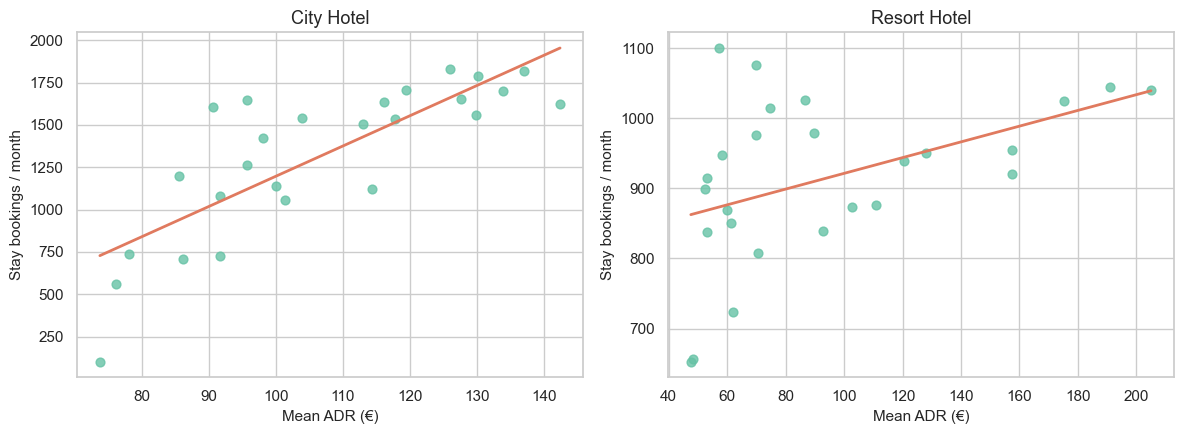

Saved: reports\figures\22_elasticity\compare\01_adr_vs_demand_scatter.png


WindowsPath('C:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/22_elasticity/compare/01_adr_vs_demand_scatter.png')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, hotel in zip(axes, HOTELS):
    sub = panel[panel["hotel"] == hotel]
    ax.scatter(sub["adr"], sub["demand"], s=40, alpha=0.8)
    z = np.polyfit(sub["adr"], sub["demand"], 1)
    xline = np.linspace(sub["adr"].min(), sub["adr"].max(), 50)
    ax.plot(xline, np.polyval(z, xline), color="#e07a5f", lw=2)
    ax.set_title(hotel)
    ax.set_xlabel("Mean ADR (€)")
    ax.set_ylabel("Stay bookings / month")
savefig("01_adr_vs_demand_scatter.png", slug="compare")

## 2. Log–log OLS + month fixed effects

$$
\log Q_{t} = \alpha + \varepsilon \log P_{t} + \sum_{m=2}^{12} \gamma_m \mathbf{1}[\mathrm{month}=m] + u_t
$$

Fit riêng từng hotel (mẫu ngắn — SE lớn là bình thường).

In [ ]:
import statsmodels.formula.api as smf

elas_rows = []
fit_store = {}

for hotel in HOTELS:
    sub = panel[panel["hotel"] == hotel].copy()
    # C(month) absorbs seasonality so epsilon is closer to price response
    model = smf.ols("log_demand ~ log_adr + C(month)", data=sub).fit()
    fit_store[hotel] = model
    eps = float(model.params["log_adr"])
    se = float(model.bse["log_adr"])
    elas_rows.append({
        "hotel": hotel,
        "method": "loglog_ols_month_fe",
        "elasticity": eps,
        "std_err": se,
        "t_stat": float(model.tvalues["log_adr"]),
        "p_value": float(model.pvalues["log_adr"]),
        "r2": float(model.rsquared),
        "n_obs": int(model.nobs),
        "ci95_low": eps - 1.96 * se,
        "ci95_high": eps + 1.96 * se,
    })
    print("=" * 60)
    print(hotel)
    print(model.summary().tables[1])

elas_ll = pd.DataFrame(elas_rows)
display(elas_ll.round(4))

City Hotel
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -8.7502      2.385     -3.668      0.003     -13.904      -3.597
C(month)[T.2]      0.0874      0.348      0.251      0.806      -0.664       0.839
C(month)[T.3]      0.2641      0.350      0.755      0.464      -0.492       1.020
C(month)[T.4]     -0.5576      0.385     -1.447      0.172      -1.390       0.275
C(month)[T.5]     -0.7957      0.409     -1.947      0.073      -1.678       0.087
C(month)[T.6]     -0.7257      0.400     -1.816      0.093      -1.589       0.138
C(month)[T.7]     -1.0195      0.336     -3.036      0.010      -1.745      -0.294
C(month)[T.8]     -0.7958      0.363     -2.195      0.047      -1.579      -0.012
C(month)[T.9]     -0.8247      0.395     -2.088      0.057      -1.678       0.028
C(month)[T.10]    -0.4810      0.371     -1.298      0.217      -1.282      

,hotel,method,elasticity,std_err,t_stat,p_value,r2,n_obs,ci95_low,ci95_high
0,City Hotel,loglog_ols_month_fe,3.5023,0.5346,6.5513,0.0000,0.826,26,2.4545,4.5502
1,Resort Hotel,loglog_ols_month_fe,0.4055,0.2256,1.7973,0.0955,0.717,26,-0.0367,0.8478


## 3. First-difference elasticity (bớt nhiễu trend)

$$
\Delta \log Q_t = \varepsilon \, \Delta \log P_t + e_t
$$

In [ ]:
fd_rows = []
for hotel in HOTELS:
    sub = panel[panel["hotel"] == hotel].sort_values("ym").copy()
    sub["d_log_q"] = sub["log_demand"].diff()
    sub["d_log_p"] = sub["log_adr"].diff()
    m = smf.ols("d_log_q ~ d_log_p - 1", data=sub.dropna()).fit()
    eps = float(m.params["d_log_p"])
    se = float(m.bse["d_log_p"])
    fd_rows.append({
        "hotel": hotel,
        "method": "first_difference",
        "elasticity": eps,
        "std_err": se,
        "t_stat": float(m.tvalues["d_log_p"]),
        "p_value": float(m.pvalues["d_log_p"]),
        "r2": float(m.rsquared),
        "n_obs": int(m.nobs),
        "ci95_low": eps - 1.96 * se,
        "ci95_high": eps + 1.96 * se,
    })
    print(hotel, f"ε_fd={eps:.3f} (SE={se:.3f})")

elas_fd = pd.DataFrame(fd_rows)
display(elas_fd.round(4))

City Hotel ε_fd=1.926 (SE=0.587)
Resort Hotel ε_fd=0.113 (SE=0.093)


,hotel,method,elasticity,std_err,t_stat,p_value,r2,n_obs,ci95_low,ci95_high
0,City Hotel,first_difference,1.9257,0.5872,3.2794,0.0032,0.3094,25,0.7748,3.0766
1,Resort Hotel,first_difference,0.1128,0.0933,1.2096,0.2382,0.0575,25,-0.0700,0.2956


## 4. Elasticity theo market segment (giảm bias mùa)

Gom `hotel × ym × market_segment` — cùng tháng, khác kênh/ADR — rồi log–log + month FE.
Nếu vẫn dương (endogeneity mạnh), dùng **RM prior** (City kém co giãn hơn Resort leisure).

In [ ]:
seg = (
    stay.groupby(["hotel", "ym", "market_segment"], as_index=False)
    .agg(demand=("adr", "size"), adr=("adr", "mean"))
)
seg = seg[seg["demand"] >= 20].copy()  # ổn định log
seg["month"] = seg["ym"].dt.month
seg["log_demand"] = np.log(seg["demand"])
seg["log_adr"] = np.log(seg["adr"].clip(lower=1e-3))

elas_seg_rows = []
for hotel in HOTELS:
    sub = seg[seg["hotel"] == hotel]
    if len(sub) < 30:
        continue
    m = smf.ols("log_demand ~ log_adr + C(month)", data=sub).fit()
    eps = float(m.params["log_adr"])
    se = float(m.bse["log_adr"])
    elas_seg_rows.append({
        "hotel": hotel,
        "method": "segment_loglog_month_fe",
        "elasticity": eps,
        "std_err": se,
        "t_stat": float(m.tvalues["log_adr"]),
        "p_value": float(m.pvalues["log_adr"]),
        "r2": float(m.rsquared),
        "n_obs": int(m.nobs),
        "ci95_low": eps - 1.96 * se,
        "ci95_high": eps + 1.96 * se,
    })
    print(hotel, f"ε_seg={eps:.3f}")

elas_seg = pd.DataFrame(elas_seg_rows)
display(elas_seg.round(4) if len(elas_seg) else "no segment fit")

City Hotel ε_seg=3.317
Resort Hotel ε_seg=1.074


,hotel,method,elasticity,std_err,t_stat,p_value,r2,n_obs,ci95_low,ci95_high
0,City Hotel,segment_loglog_month_fe,3.3170,0.4456,7.4432,0.0000,0.3432,124,2.4436,4.1905
1,Resort Hotel,segment_loglog_month_fe,1.0741,0.2818,3.8117,0.0002,0.2287,113,0.5218,1.6265


## 5. Chọn elasticity vận hành + prior an toàn

Thứ tự ưu tiên (chỉ nhận $\varepsilon < 0$):

1. segment log–log  
2. monthly log–log + month FE  
3. first-difference  
4. **prior RM**: City $-0.70$, Resort $-1.10$

Clip $[-2.5,\,-0.15]$.

In [ ]:
RM_PRIOR = {"City Hotel": -0.70, "Resort Hotel": -1.10}


def pick_primary(hotel: str) -> tuple[float, str, str]:
    cands: list[tuple[float, str]] = []
    for df, method in (
        (elas_seg, "segment_loglog_month_fe"),
        (elas_ll, "loglog_ols_month_fe"),
        (elas_fd, "first_difference"),
    ):
        hit = df.loc[df["hotel"] == hotel] if len(df) else df
        if len(hit):
            e = float(hit.iloc[0]["elasticity"])
            if np.isfinite(e) and e < 0:
                cands.append((e, method))
    if cands:
        e, method = cands[0]
        note = "data-driven (negative)"
    else:
        e, method = RM_PRIOR[hotel], "rm_prior"
        note = "OLS biased positive (seasonality/endogeneity) -> RM prior"
    return float(np.clip(e, -2.5, -0.15)), method, note


primary_rows = []
for hotel in HOTELS:
    ll = elas_ll.loc[elas_ll["hotel"] == hotel].iloc[0]
    fd = elas_fd.loc[elas_fd["hotel"] == hotel].iloc[0]
    seg_e = (
        float(elas_seg.loc[elas_seg["hotel"] == hotel, "elasticity"].iloc[0])
        if len(elas_seg) and hotel in set(elas_seg["hotel"])
        else np.nan
    )
    eps, src, note = pick_primary(hotel)
    primary_rows.append({
        "hotel": hotel,
        "elasticity_primary": eps,
        "source_method": src,
        "elasticity_loglog": float(ll["elasticity"]),
        "elasticity_fd": float(fd["elasticity"]),
        "elasticity_segment": seg_e,
        "note": note,
    })

primary = pd.DataFrame(primary_rows)
display(primary.round(4))

elas_all = pd.concat([elas_ll, elas_fd, elas_seg], ignore_index=True)
elas_all.to_csv(FIG_DIR / "elasticity_estimates_all.csv", index=False)
primary.to_csv(FIG_DIR / "elasticity_by_hotel.csv", index=False)
print("Saved elasticity_by_hotel.csv")

,hotel,elasticity_primary,source_method,elasticity_loglog,elasticity_fd,elasticity_segment,note
0,City Hotel,-0.7,rm_prior,3.5023,1.9257,3.3170,OLS biased positive (seasonality/endogeneity) ...
1,Resort Hotel,-1.1,rm_prior,0.4055,0.1128,1.0741,OLS biased positive (seasonality/endogeneity) ...


Saved elasticity_by_hotel.csv


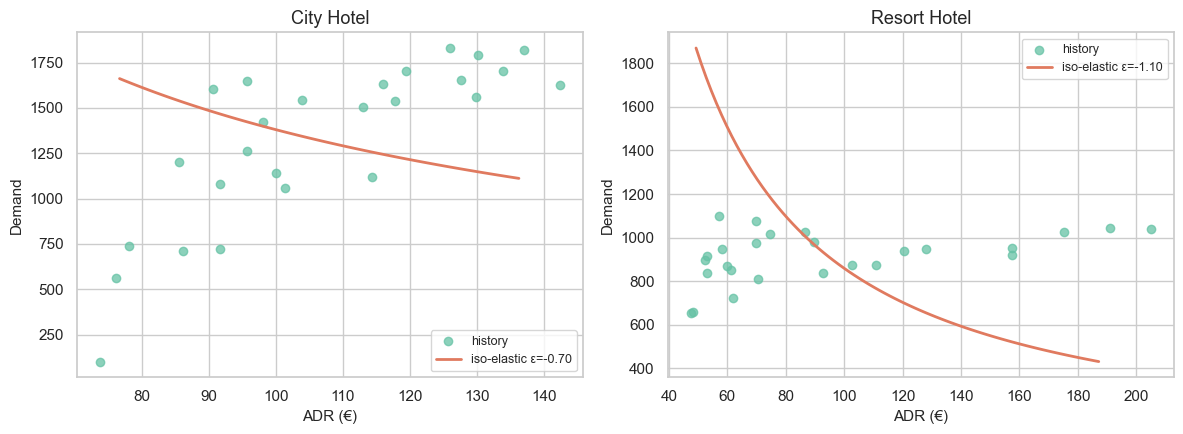

Saved: reports\figures\22_elasticity\compare\02_isoelastic_curves.png


WindowsPath('C:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/22_elasticity/compare/02_isoelastic_curves.png')

In [ ]:
# Fitted iso-elastic curves around mean ADR
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, hotel in zip(axes, HOTELS):
    sub = panel[panel["hotel"] == hotel]
    eps = primary.loc[primary["hotel"] == hotel, "elasticity_primary"].iloc[0]
    p0 = sub["adr"].mean()
    q0 = sub["demand"].mean()
    grid = np.linspace(sub["adr"].quantile(0.05), sub["adr"].quantile(0.95), 80)
    q_hat = q0 * (grid / p0) ** eps
    ax.scatter(sub["adr"], sub["demand"], alpha=0.75, label="history")
    ax.plot(grid, q_hat, color="#e07a5f", lw=2, label=f"iso-elastic ε={eps:.2f}")
    ax.set_title(hotel)
    ax.set_xlabel("ADR (€)")
    ax.set_ylabel("Demand")
    ax.legend(fontsize=9)
savefig("02_isoelastic_curves.png", slug="compare")

## 6. Diễn giải nhanh

| | Đọc |
|---|---|
| $\varepsilon \approx -1$ | Đổi giá 1% → đổi demand ~1% ngược chiều |
| $|\varepsilon| < 1$ | Demand kém co giãn → dễ **PROTECT** giá hơn |
| $|\varepsilon| > 1$ | Co giãn mạnh → promo/% giảm giá hiệu quả hơn khi STIMULATE |

**Hạn chế:** ADR nội sinh theo mùa → OLS tháng dễ dương; segment FE / prior RM dùng khi dấu sai. Notebook 23 dùng $\varepsilon$ như **tham số điều khiển**, kèm sensitivity nếu cần.